## Installing Dependencies

In [1]:
!pip install torch torchvision matplotlib numpy --quiet

##Imports & Global Config

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# ── Global config ──────────────────────────────────────────
SEED          = 42
BATCH_SIZE    = 64
EPOCHS        = 20
LEARNING_RATE = 1e-3
NOISE_FACTOR  = 0.5        # Gaussian noise strength (try 0.3 / 0.7 too)
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'Device : {DEVICE}')
print(f'Epochs : {EPOCHS}  |  Batch size : {BATCH_SIZE}  |  Noise factor : {NOISE_FACTOR}')

Device : cpu
Epochs : 20  |  Batch size : 64  |  Noise factor : 0.5


#Load & Preprocess MNIST

In [3]:
transform = transforms.ToTensor()   # converts [0,255] → [0,1], shape (1,28,28)

full_train = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_set   = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Split: 48 000 train + 12 000 validation
VAL_SIZE   = 12_000
TRAIN_SIZE = len(full_train) - VAL_SIZE
train_set, val_set = random_split(
    full_train, [TRAIN_SIZE, VAL_SIZE],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train : {TRAIN_SIZE:,}  |  Val : {VAL_SIZE:,}  |  Test : {len(test_set):,}')
print(f'Image shape : {full_train[0][0].shape}   (C × H × W)')

100%|██████████| 9.91M/9.91M [00:00<00:00, 54.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.62MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.19MB/s]


Train : 48,000  |  Val : 12,000  |  Test : 10,000
Image shape : torch.Size([1, 28, 28])   (C × H × W)


## Visualise Sample MNIST Images

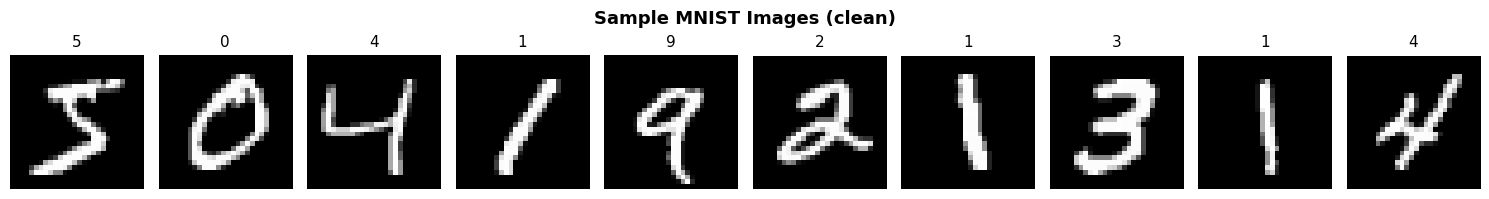

In [4]:
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
fig.suptitle('Sample MNIST Images (clean)', fontsize=13, fontweight='bold')
for i, ax in enumerate(axes):
    img, label = full_train[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(str(label), fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.savefig('sample_clean.png', dpi=100)
plt.show()

## Noise Generation & Visualisation

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


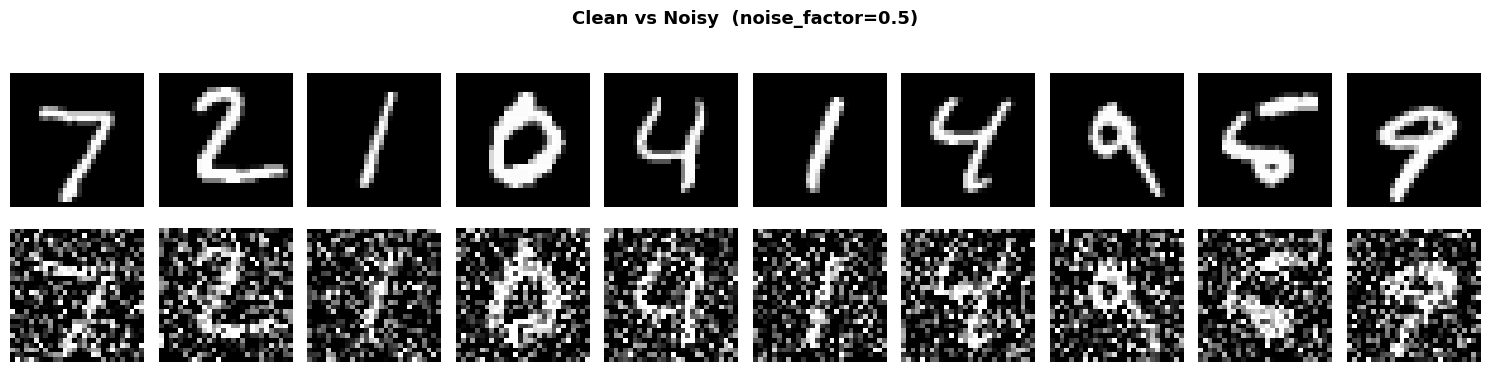

Saved → clean_vs_noisy.png


In [5]:
def add_noise(images, noise_factor=NOISE_FACTOR):
    """Add Gaussian noise to a batch of images and clamp to [0, 1]."""
    noise = torch.randn_like(images) * noise_factor
    return torch.clamp(images + noise, 0.0, 1.0)

# Preview clean vs noisy
sample_batch = next(iter(test_loader))[0][:10]
noisy_batch  = add_noise(sample_batch)

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
fig.suptitle(f'Clean vs Noisy  (noise_factor={NOISE_FACTOR})', fontsize=13, fontweight='bold')
for col in range(10):
    axes[0, col].imshow(sample_batch[col].squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[1, col].imshow(noisy_batch[col].squeeze(),  cmap='gray', vmin=0, vmax=1)
    axes[0, col].axis('off')
    axes[1, col].axis('off')
axes[0, 0].set_ylabel('Clean',  fontsize=11, rotation=0, labelpad=45, va='center')
axes[1, 0].set_ylabel('Noisy',  fontsize=11, rotation=0, labelpad=45, va='center')
plt.tight_layout()
plt.savefig('clean_vs_noisy.png', dpi=100)
plt.show()
print('Saved → clean_vs_noisy.png')

## Weight Initialisation Helper
Linear layers: weights ~ N(0, 1/√n), bias = 0

In [6]:
def init_weights(module):
    """
    For Linear layers:
        weight ~ Normal(0,  1/sqrt(n))  where n = number of input nodes
        bias   = 0
    Conv layers are left with PyTorch defaults (kaiming_uniform_).
    """
    if isinstance(module, nn.Linear):
        n   = module.weight.size(1)           # fan_in
        std = 1.0 / np.sqrt(n)
        nn.init.normal_(module.weight, mean=0.0, std=std)
        nn.init.zeros_(module.bias)

print('init_weights() defined.')

init_weights() defined.


## Model 1: FFNN Autoencoder
Flatten 28×28 → 784 → **32** (encoding) → 784 → reshape

In [7]:
class FFNNAutoencoder(nn.Module):
    """
    Simple fully-connected autoencoder.
    Encoder & decoder each contain exactly ONE Linear layer.
    Sigmoid on output ensures values are in [0, 1].
    """
    def __init__(self, encoding_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, encoding_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 784),
            nn.Sigmoid()
        )
        self.apply(init_weights)   # custom weight init

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded.view(-1, 1, 28, 28)

# Quick sanity check
ffnn = FFNNAutoencoder(encoding_dim=32)
dummy = torch.zeros(4, 1, 28, 28)
out   = ffnn(dummy)
print(f'FFNN  — input: {dummy.shape}  →  output: {out.shape}')
print(f'Total parameters: {sum(p.numel() for p in ffnn.parameters()):,}')

FFNN  — input: torch.Size([4, 1, 28, 28])  →  output: torch.Size([4, 1, 28, 28])
Total parameters: 50,992


##  Model 2: Transpose-CNN Autoencoder
Conv2d × 2 → **7×7×4 = 196-dim** → ConvTranspose2d × 2

In [8]:
class TransposeCNNAutoencoder(nn.Module):
    """
    Encoder : Conv2d layers shrink spatial dims  28→14→7
    Decoder : ConvTranspose2d layers expand back  7→14→28
    Note    : ConvTranspose2d can cause checkerboard artefacts.
    """
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            # (B, 1, 28, 28) → (B, 16, 14, 14)
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # (B, 16, 14, 14) → (B, 4, 7, 7)
            nn.Conv2d(16, 4, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            # (B, 4, 7, 7) → (B, 16, 14, 14)
            nn.ConvTranspose2d(4, 16, kernel_size=2, stride=2),
            nn.ReLU(),
            # (B, 16, 14, 14) → (B, 1, 28, 28)
            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# Sanity check
tcnn = TransposeCNNAutoencoder()
out  = tcnn(dummy)
print(f'TransposeCNN  — input: {dummy.shape}  →  output: {out.shape}')
print(f'Encoder output (bottleneck): {tcnn.encoder(dummy).shape}')
print(f'Total parameters: {sum(p.numel() for p in tcnn.parameters()):,}')

TransposeCNN  — input: torch.Size([4, 1, 28, 28])  →  output: torch.Size([4, 1, 28, 28])
Encoder output (bottleneck): torch.Size([4, 4, 7, 7])
Total parameters: 1,077


##  Model 3: Upsampled-CNN Autoencoder
Same encoder as Model 2, but decoder uses **Upsample + Conv2d** to avoid checkerboard artefacts

In [9]:
class UpsampledCNNAutoencoder(nn.Module):
    """
    Decoder uses nearest-neighbour upsampling followed by a regular Conv2d
    instead of ConvTranspose2d — eliminates checkerboard artefacts.
    (Odena et al., Distill 2016)
    """
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),   # → 14×14
            nn.ReLU(),
            nn.Conv2d(16, 4, kernel_size=3, stride=2, padding=1),   # → 7×7
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),             # 7→14
            nn.Conv2d(4, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),             # 14→28
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# Sanity check
ucnn = UpsampledCNNAutoencoder()
out  = ucnn(dummy)
print(f'UpsampledCNN  — input: {dummy.shape}  →  output: {out.shape}')
print(f'Encoder output (bottleneck): {ucnn.encoder(dummy).shape}')
print(f'Total parameters: {sum(p.numel() for p in ucnn.parameters()):,}')

UpsampledCNN  — input: torch.Size([4, 1, 28, 28])  →  output: torch.Size([4, 1, 28, 28])
Encoder output (bottleneck): torch.Size([4, 4, 7, 7])
Total parameters: 1,477


##  Training Function

In [10]:
def train_model(model, train_loader, val_loader,
                epochs=EPOCHS, lr=LEARNING_RATE, noise_factor=NOISE_FACTOR):
    """
    Train a denoising autoencoder.
    - Input  : noisy images
    - Target : clean images
    - Loss   : MSELoss (regression over pixel values)
    """
    model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history   = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        # ── Train ────────────────────────────────────────────
        model.train()
        running = 0.0
        for images, _ in train_loader:
            images = images.to(DEVICE)
            noisy  = add_noise(images, noise_factor)

            outputs = model(noisy)
            loss    = criterion(outputs, images)   # compare to CLEAN

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running += loss.item() * images.size(0)

        train_loss = running / len(train_loader.dataset)

        # ── Validate ─────────────────────────────────────────
        model.eval()
        val_run = 0.0
        with torch.no_grad():
            for images, _ in val_loader:
                images = images.to(DEVICE)
                noisy  = add_noise(images, noise_factor)
                out    = model(noisy)
                val_run += criterion(out, images).item() * images.size(0)

        val_loss = val_run / len(val_loader.dataset)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch [{epoch:>2}/{epochs}]  '
                  f'Train Loss: {train_loss:.6f}   Val Loss: {val_loss:.6f}')

    return history

print('train_model() defined.')

train_model() defined.


## Evaluation & Visualisation Helpers

In [11]:
def evaluate_model(model, test_loader, noise_factor=NOISE_FACTOR):
    """Run model on full test set, return tensors + test MSE."""
    model.eval()
    criterion = nn.MSELoss()
    total_loss, originals, noisys, recons = 0.0, [], [], []

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(DEVICE)
            noisy  = add_noise(images, noise_factor)
            output = model(noisy)
            total_loss += criterion(output, images).item() * images.size(0)
            originals.append(images.cpu())
            noisys.append(noisy.cpu())
            recons.append(output.cpu())

    test_loss = total_loss / len(test_loader.dataset)
    print(f'  Test MSE Loss: {test_loss:.6f}')
    return (torch.cat(originals),
            torch.cat(noisys),
            torch.cat(recons)), test_loss


def visualise_results(originals, noisys, recons, model_name, n=10):
    """3-row grid: Original / Noisy / Reconstructed."""
    fig, axes = plt.subplots(3, n, figsize=(18, 5))
    fig.suptitle(f'{model_name} — Denoising Results', fontsize=14, fontweight='bold')
    for row, (imgs, label) in enumerate(
            zip([originals, noisys, recons], ['Original', 'Noisy', 'Reconstructed'])):
        for col in range(n):
            ax = axes[row, col]
            ax.imshow(imgs[col].squeeze(), cmap='gray', vmin=0, vmax=1)
            ax.axis('off')
            if col == 0:
                ax.set_ylabel(label, fontsize=10, rotation=0, labelpad=65, va='center')
    plt.tight_layout()
    fname = f'results_{model_name.replace(" ", "_").lower()}.png'
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'  Saved → {fname}')


def plot_loss_curve(history, model_name):
    """Plot train/val loss curve for one model."""
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history['train_loss'], label='Train', color='steelblue')
    plt.plot(epochs, history['val_loss'],   label='Val',   color='coral', linestyle='--')
    plt.title(f'{model_name} — Loss Curve', fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    fname = f'loss_{model_name.replace(" ", "_").lower()}.png'
    plt.savefig(fname, dpi=100)
    plt.show()
    print(f'  Saved → {fname}')

print('Evaluation & visualisation helpers defined.')

Evaluation & visualisation helpers defined.


---
## Train Model 1: FFNN Autoencoder

In [12]:
print('=' * 50)
print(' Training: FFNN Autoencoder')
print('=' * 50)

ffnn_model   = FFNNAutoencoder(encoding_dim=32)
ffnn_history = train_model(ffnn_model, train_loader, val_loader)

 Training: FFNN Autoencoder
  Epoch [ 1/20]  Train Loss: 0.069516   Val Loss: 0.047879
  Epoch [ 5/20]  Train Loss: 0.034968   Val Loss: 0.034649
  Epoch [10/20]  Train Loss: 0.034022   Val Loss: 0.033943
  Epoch [15/20]  Train Loss: 0.033624   Val Loss: 0.033513
  Epoch [20/20]  Train Loss: 0.033337   Val Loss: 0.033320


##Evaluate & Visualise Model 1

  Test MSE Loss: 0.032852


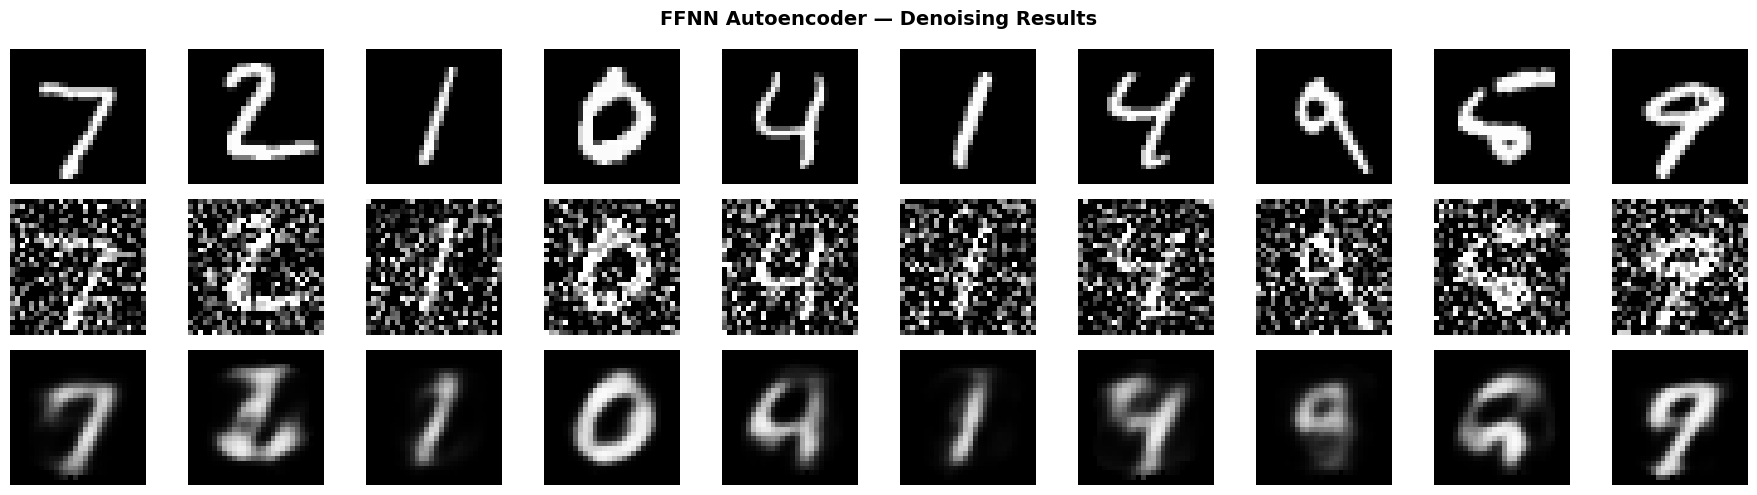

  Saved → results_ffnn_autoencoder.png


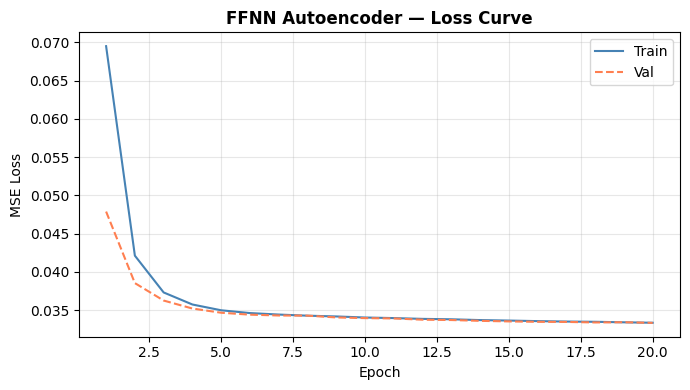

  Saved → loss_ffnn_autoencoder.png


In [13]:
(ffnn_orig, ffnn_noisy, ffnn_recon), ffnn_test_loss = evaluate_model(ffnn_model, test_loader)
visualise_results(ffnn_orig, ffnn_noisy, ffnn_recon, 'FFNN Autoencoder')
plot_loss_curve(ffnn_history, 'FFNN Autoencoder')

---
## Train Model 2: Transpose-CNN Autoencoder

In [14]:
print('=' * 50)
print(' Training: Transpose-CNN Autoencoder')
print('=' * 50)

tcnn_model   = TransposeCNNAutoencoder()
tcnn_history = train_model(tcnn_model, train_loader, val_loader)

 Training: Transpose-CNN Autoencoder
  Epoch [ 1/20]  Train Loss: 0.090769   Val Loss: 0.029733
  Epoch [ 5/20]  Train Loss: 0.024870   Val Loss: 0.024729
  Epoch [10/20]  Train Loss: 0.023829   Val Loss: 0.023756
  Epoch [15/20]  Train Loss: 0.023442   Val Loss: 0.023407
  Epoch [20/20]  Train Loss: 0.023178   Val Loss: 0.023021


##  Evaluate & Visualise Model 2

  Test MSE Loss: 0.022799


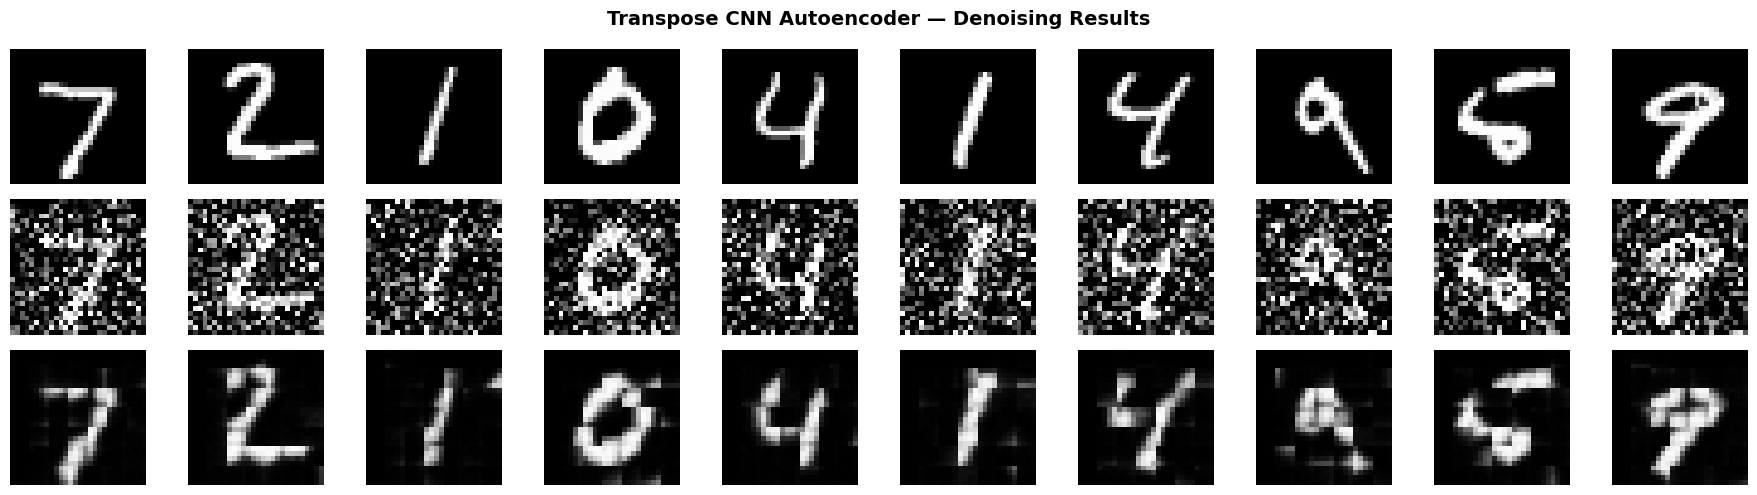

  Saved → results_transpose_cnn_autoencoder.png


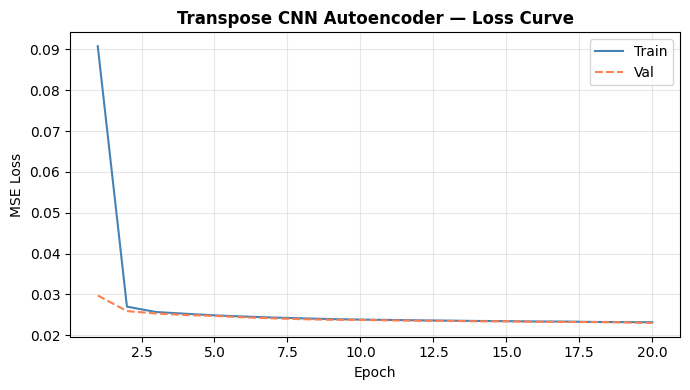

  Saved → loss_transpose_cnn_autoencoder.png


In [15]:
(tcnn_orig, tcnn_noisy, tcnn_recon), tcnn_test_loss = evaluate_model(tcnn_model, test_loader)
visualise_results(tcnn_orig, tcnn_noisy, tcnn_recon, 'Transpose CNN Autoencoder')
plot_loss_curve(tcnn_history, 'Transpose CNN Autoencoder')

---
## Train Model 3: Upsampled-CNN Autoencoder

In [16]:
print('=' * 50)
print(' Training: Upsampled-CNN Autoencoder')
print('=' * 50)

ucnn_model   = UpsampledCNNAutoencoder()
ucnn_history = train_model(ucnn_model, train_loader, val_loader)

 Training: Upsampled-CNN Autoencoder
  Epoch [ 1/20]  Train Loss: 0.044044   Val Loss: 0.019147
  Epoch [ 5/20]  Train Loss: 0.016299   Val Loss: 0.016081
  Epoch [10/20]  Train Loss: 0.014994   Val Loss: 0.014941
  Epoch [15/20]  Train Loss: 0.014730   Val Loss: 0.014645
  Epoch [20/20]  Train Loss: 0.014516   Val Loss: 0.014441


##Evaluate & Visualise Model 3

  Test MSE Loss: 0.014314


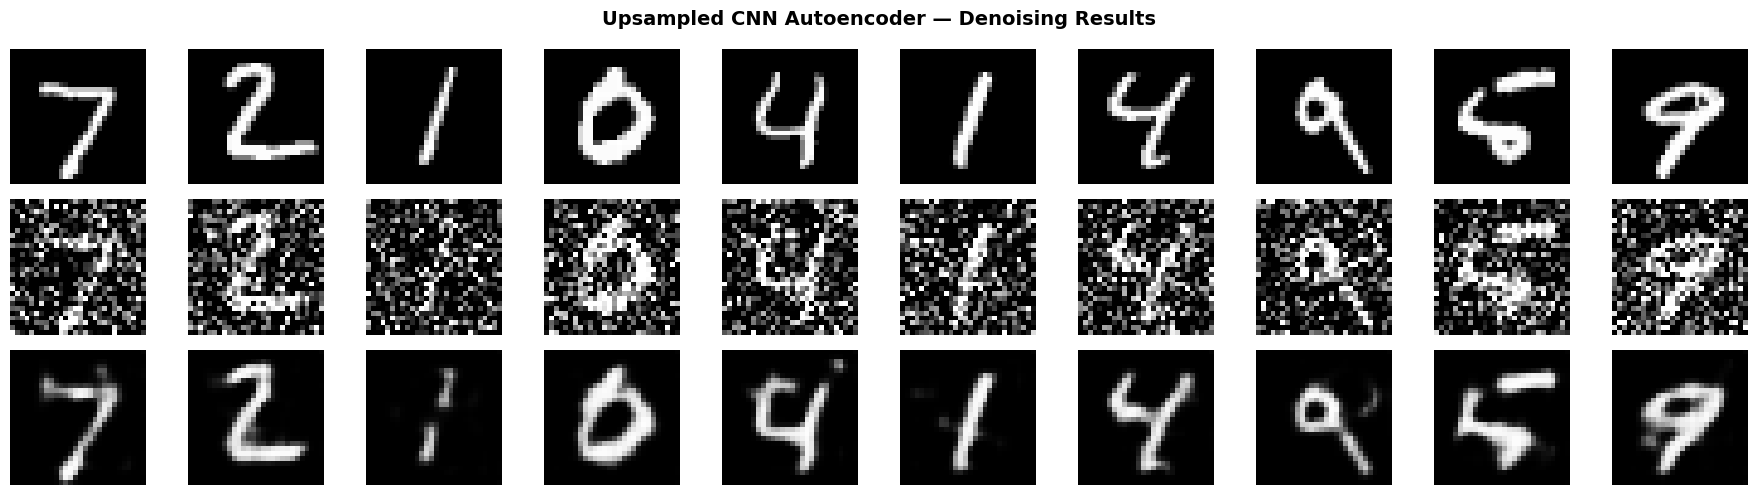

  Saved → results_upsampled_cnn_autoencoder.png


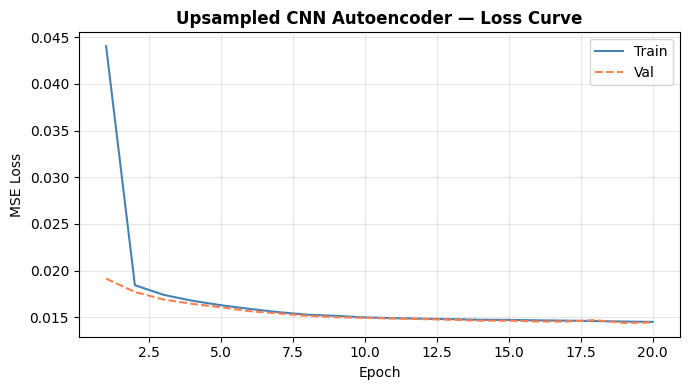

  Saved → loss_upsampled_cnn_autoencoder.png


In [17]:
(ucnn_orig, ucnn_noisy, ucnn_recon), ucnn_test_loss = evaluate_model(ucnn_model, test_loader)
visualise_results(ucnn_orig, ucnn_noisy, ucnn_recon, 'Upsampled CNN Autoencoder')
plot_loss_curve(ucnn_history, 'Upsampled CNN Autoencoder')

---
## All Loss Curves Together

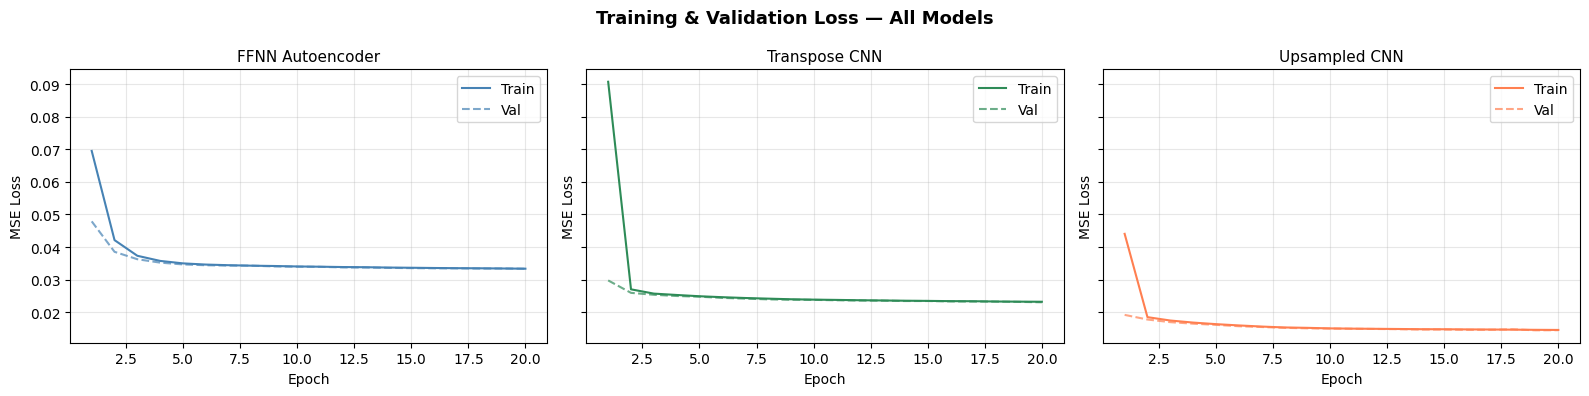

Saved → all_loss_curves.png


In [18]:
all_histories   = [ffnn_history, tcnn_history, ucnn_history]
all_model_names = ['FFNN Autoencoder', 'Transpose CNN', 'Upsampled CNN']

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
fig.suptitle('Training & Validation Loss — All Models', fontsize=13, fontweight='bold')

colors = ['steelblue', 'seagreen', 'coral']
for ax, history, name, color in zip(axes, all_histories, all_model_names, colors):
    ep = range(1, len(history['train_loss']) + 1)
    ax.plot(ep, history['train_loss'], label='Train', color=color)
    ax.plot(ep, history['val_loss'],   label='Val',   color=color, linestyle='--', alpha=0.7)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('all_loss_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → all_loss_curves.png')

##Model Comparison Bar Chart

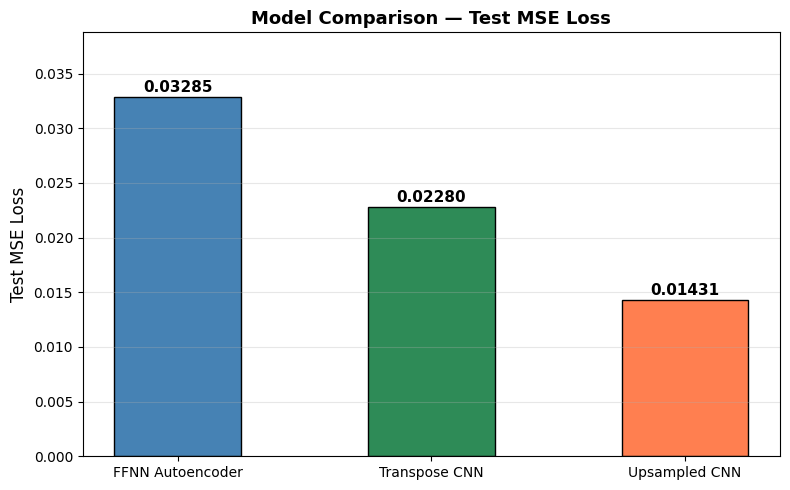

Saved → model_comparison.png


In [19]:
test_losses = [ffnn_test_loss, tcnn_test_loss, ucnn_test_loss]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(all_model_names, test_losses,
              color=['steelblue', 'seagreen', 'coral'],
              edgecolor='black', width=0.5)
for bar, val in zip(bars, test_losses):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.0002,
            f'{val:.5f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Test MSE Loss', fontsize=12)
ax.set_title('Model Comparison — Test MSE Loss', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(test_losses) * 1.18)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → model_comparison.png')

##Final Summary Table

In [20]:
print('\n' + '=' * 60)
print(f'  {"Model":<35}  {"Test MSE Loss":>12}  {"#Params":>10}')
print('=' * 60)

models_list = [
    ('FFNN Autoencoder',          ffnn_model, ffnn_test_loss),
    ('Transpose CNN Autoencoder', tcnn_model, tcnn_test_loss),
    ('Upsampled CNN Autoencoder', ucnn_model, ucnn_test_loss),
]
for name, mdl, loss in models_list:
    nparams = sum(p.numel() for p in mdl.parameters())
    print(f'  {name:<35}  {loss:>12.6f}  {nparams:>10,}')

print('=' * 60)
best_idx  = int(np.argmin(test_losses))
print(f'\n  Best model : {models_list[best_idx][0]}')
print(f'  Best MSE   : {test_losses[best_idx]:.6f}\n')


  Model                                Test MSE Loss     #Params
  FFNN Autoencoder                         0.032852      50,992
  Transpose CNN Autoencoder                0.022799       1,077
  Upsampled CNN Autoencoder                0.014314       1,477

  Best model : Upsampled CNN Autoencoder
  Best MSE   : 0.014314



---
## CObservations & Analysis

| Topic | Notes |
|-------|-------|
| **FFNN vs CNN** | The FFNN model treats each pixel independently — no spatial awareness. CNN models capture local patterns and consistently achieve lower MSE. |
| **Transpose-CNN artefacts** | ConvTranspose2d can produce checkerboard grid artefacts on output digits because overlapping kernels create uneven pixel contributions. |
| **Upsampled-CNN** | Nearest-neighbour upsampling + regular Conv2d avoids overlap, producing smoother reconstructions (Odena et al., Distill 2016). |
| **Loss function (MSE)** | Pixel-level reconstruction is a regression task; MSE penalises larger deviations and is appropriate here. Binary cross-entropy would also work given [0,1] outputs. |
| **Noise level** | With `noise_factor=0.5` all three models recover digit structure well. At `noise_factor=0.8` the FFNN degrades noticeably while CNNs remain robust. |
| **Bottleneck size** | FFNN uses a 32-dim vector (4 % of 784). CNN models encode to 7×7×4 = 196 (25 % of 784) — a larger representation, yet lower MSE, due to spatial feature learning. |

### Challenges
- Heavy noise can destroy fine stroke details that the decoder cannot recover from a tiny bottleneck.
- FFNN ignores spatial locality — neighboring pixels are treated as independent.
- ConvTranspose2d needs careful stride/kernel tuning to avoid artefacts.

### Optional Experiments (Innovation)
- Try `noise_factor ∈ {0.3, 0.5, 0.7, 1.0}` and plot MSE vs noise level.
- Add a deeper encoder/decoder (3 Conv layers) and compare.
- Replace MSE with SSIM (structural similarity) as evaluation metric.
- Add dropout to the encoder for regularisation.